In [1]:
#!pip install kagglehub
import kagglehub

# Visualizações (virgem, que tanto de biblioteca!!! trouxe várias pra deixar pra vocês brincarem!)
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
# Estatísticas 
from scipy import stats
import warnings

# Configurações
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Configurações do matplotlib (calma que amanhã tem dataviz! hoje é só uns gráficos simples)
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
# Configurações do pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)


### Dowload dos dados 

In [2]:
path = kagglehub.dataset_download("nancyalaswad90/lung-cancer")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\55119\.cache\kagglehub\datasets\nancyalaswad90\lung-cancer\versions\6


In [3]:
base_path = r"C:\Users\55119\.cache\kagglehub\datasets\nancyalaswad90\lung-cancer\versions\6"
file_name = os.listdir(base_path)[0]

df = pd.read_csv(os.path.join(base_path, file_name))

### Visualização inicial

In [4]:
df.info()
display(df.head())
shape = df.shape
print(f"Total de linhas e colunas: {shape}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 309 non-null    object
 1   AGE                    309 non-null    int64 
 2   SMOKING                309 non-null    int64 
 3   YELLOW_FINGERS         309 non-null    int64 
 4   ANXIETY                309 non-null    int64 
 5   PEER_PRESSURE          309 non-null    int64 
 6   CHRONIC DISEASE        309 non-null    int64 
 7   FATIGUE                309 non-null    int64 
 8   ALLERGY                309 non-null    int64 
 9   WHEEZING               309 non-null    int64 
 10  ALCOHOL CONSUMING      309 non-null    int64 
 11  COUGHING               309 non-null    int64 
 12  SHORTNESS OF BREATH    309 non-null    int64 
 13  SWALLOWING DIFFICULTY  309 non-null    int64 
 14  CHEST PAIN             309 non-null    int64 
 15  LUNG_CANCER            

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


Total de linhas e colunas: (309, 16)


### Dicionário dos dados 

| Variable              | Description (English)                               | Descrição (Português)                                               | Type                 | Coding               |
| --------------------- | --------------------------------------------------- | ------------------------------------------------------------------- | -------------------- | -------------------- |
| GENDER                | Gender of the individual                            | Sexo do indivíduo                                                   | Categorical          | M = Male; F = Female |
| AGE                   | Age in years                                        | Idade em anos                                                       | Numeric (continuous) | Years                |
| SMOKING               | Smoking habits                                      | Hábito de tabagismo                                                 | Binary               | 1 = Yes; 2 = No      |
| YELLOW_FINGERS        | Presence of yellow fingers, often linked to smoking | Presença de dedos amarelados, frequentemente associada ao tabagismo | Binary               | 1 = Yes; 2 = No      |
| ANXIETY               | Reports anxiety                                     | Relato de ansiedade                                                 | Binary               | 1 = Yes; 2 = No      |
| PEER_PRESSURE         | Peer influence on lifestyle                         | Influência de pares no estilo de vida                               | Binary               | 1 = Yes; 2 = No      |
| CHRONIC_DISEASE       | Presence of any chronic disease                     | Presença de doença crônica                                          | Binary               | 1 = Yes; 2 = No      |
| FATIGUE               | Reports fatigue symptoms                            | Relato de sintomas de fadiga                                        | Binary               | 1 = Yes; 2 = No      |
| ALLERGY               | Presence of allergies                               | Presença de alergias                                                | Binary               | 1 = Yes; 2 = No      |
| WHEEZING              | Wheezing symptoms present or not                    | Presença de chiado respiratório                                     | Binary               | 1 = Yes; 2 = No      |
| ALCOHOL_CONSUMING     | Alcohol consumption habits                          | Hábito de consumo de álcool                                         | Binary               | 1 = Yes; 2 = No      |
| COUGHING              | Frequency or presence of coughing                   | Frequência ou presença de tosse                                     | Binary               | 1 = Yes; 2 = No      |
| SHORTNESS_OF_BREATH   | Reports of breathing difficulties                   | Relato de falta de ar                                               | Binary               | 1 = Yes; 2 = No      |
| SWALLOWING_DIFFICULTY | Difficulty swallowing                               | Dificuldade para engolir                                            | Binary               | 1 = Yes; 2 = No      |
| CHEST_PAIN            | Presence of chest pain                              | Presença de dor torácica                                            | Binary               | 1 = Yes; 2 = No      |
| LUNG_CANCER           | Lung cancer diagnosis (target variable)             | Diagnóstico de câncer de pulmão (variável alvo)                     | Binary               | Yes; No              |


### Data wrangling 

In [5]:
#### padronizaçào dos nomes das colunas
df.columns = (
    df.columns
    .str.strip()          # remove espaços extras
    .str.lower()          # tudo minúsculo
    .str.replace(" ", "_") # troca espaço por _
)

### padronização das classes
df[['smoking', 'yellow_fingers', 'anxiety',
       'peer_pressure', 'chronic_disease', 'fatigue', 'allergy', 'wheezing',
       'alcohol_consuming', 'coughing', 'shortness_of_breath',
       'swallowing_difficulty', 'chest_pain']] = df[['smoking', 'yellow_fingers', 'anxiety',
       'peer_pressure', 'chronic_disease', 'fatigue', 'allergy', 'wheezing',
       'alcohol_consuming', 'coughing', 'shortness_of_breath',
       'swallowing_difficulty', 'chest_pain']].replace({1: 0, 2: 1})

df["gender"]= df["gender"].replace({"M": 1, "F": 0})
df["lung_cancer"]= df["lung_cancer"].replace({"YES": 1, "NO": 0})

### Visualização dos dados organizados

In [6]:
df.head()

,gender,age,smoking,yellow_fingers,anxiety,peer_pressure,chronic_disease,fatigue,allergy,wheezing,alcohol_consuming,coughing,shortness_of_breath,swallowing_difficulty,chest_pain,lung_cancer
0,1,69,0,1,1,0,0,1,0,1,1,1,1,1,1,1
1,1,74,1,0,0,0,1,1,1,0,0,0,1,1,1,1
2,0,59,0,0,0,1,0,1,0,1,0,1,1,0,1,0
3,1,63,1,1,1,0,0,0,0,0,1,0,0,1,1,0
4,0,63,0,1,0,0,0,0,0,1,0,1,1,0,0,0


### Estatística descritiva 

#### Variável idade

In [7]:
df["age"].describe()

count    309.000000
mean      62.673139
std        8.210301
min       21.000000
25%       57.000000
50%       62.000000
75%       69.000000
max       87.000000
Name: age, dtype: float64

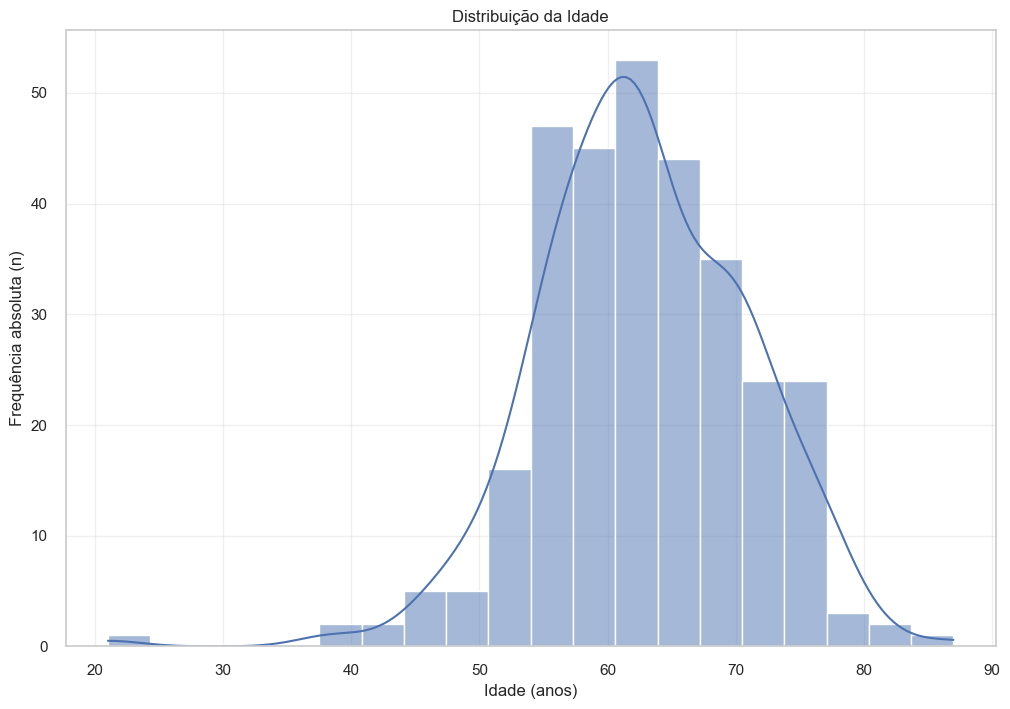

In [8]:
sns.set_theme(style="whitegrid")
sns.histplot(data=df, x="age", bins=20, kde=True, palette='viridis')
plt.title("Distribuição da Idade")
plt.xlabel("Idade (anos)")
plt.ylabel("Frequência absoluta (n)")
plt.show()

### Presença de câncer de pulmões

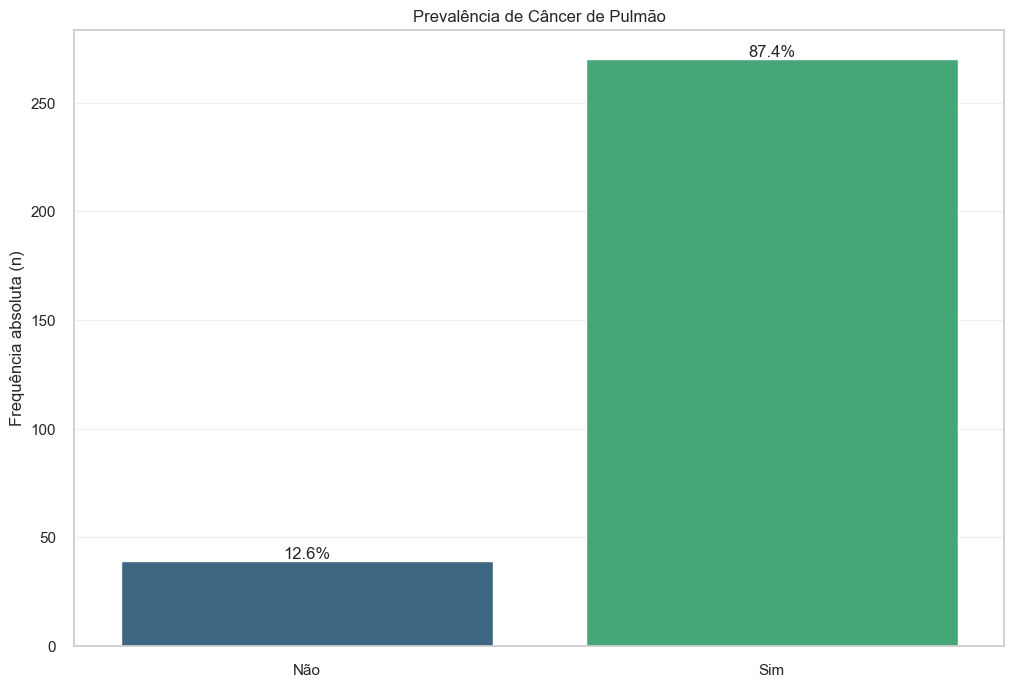

In [9]:
sns.set_theme(style="whitegrid")
ax=sns.countplot(data=df, x="lung_cancer", palette='viridis', order=[0, 1])
total = len(df)

for p in ax.patches:
    altura = p.get_height()
    porcentagem = 100 * altura / total
    ax.annotate(f'{porcentagem:.1f}%',
                (p.get_x() + p.get_width() / 2, altura),
                ha='center', va='bottom')

ax.set_xticklabels(["Não", "Sim"])
plt.title("Prevalência de Câncer de Pulmão")
plt.xlabel("")
plt.ylabel("Frequência absoluta (n)")
plt.show()

### Fumantes 

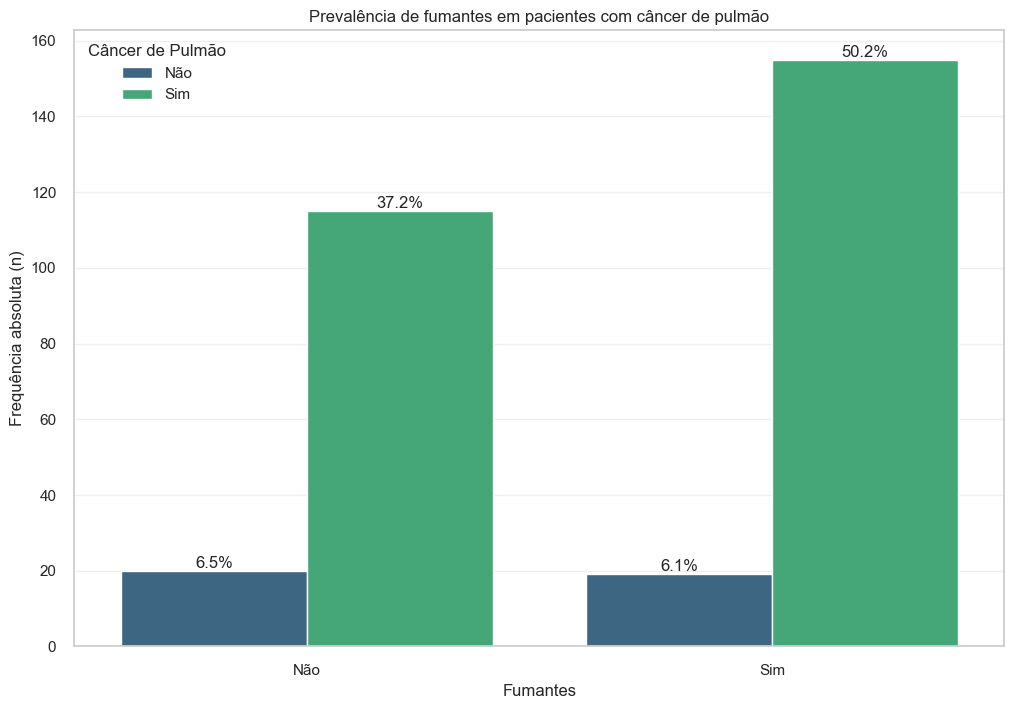

In [10]:
sns.set_theme(style="whitegrid")

ax = sns.countplot(
    data=df,
    x="smoking",
    hue="lung_cancer",
    order=[0, 1],
    
    palette="viridis"
)

### calculando a porcenmtagem para as barras
total = len(df)

for p in ax.patches:
    altura = p.get_height()
    
    if altura == 0:   # ignora barras invisíveis
        continue
    
    porcentagem = 100 * altura / total
    
    ax.annotate(
        f'{porcentagem:.1f}%',
        (p.get_x() + p.get_width() / 2, altura),
        ha='center',
        va='bottom'
    )
#### renomeando labels do eixo X
ax.set_xticks([0, 1])
ax.set_xticklabels(["Não", "Sim"])

#### Alterndo label da legenda 
handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles,
    ["Não", "Sim"],   # ordem depende de como está no dataset
    title="Câncer de Pulmão"
)

### Parte escrita 
plt.title("Prevalência de fumantes em pacientes com câncer de pulmão")
plt.xlabel("Fumantes")
plt.ylabel("Frequência absoluta (n)")
plt.show()

### Presença de fadiga

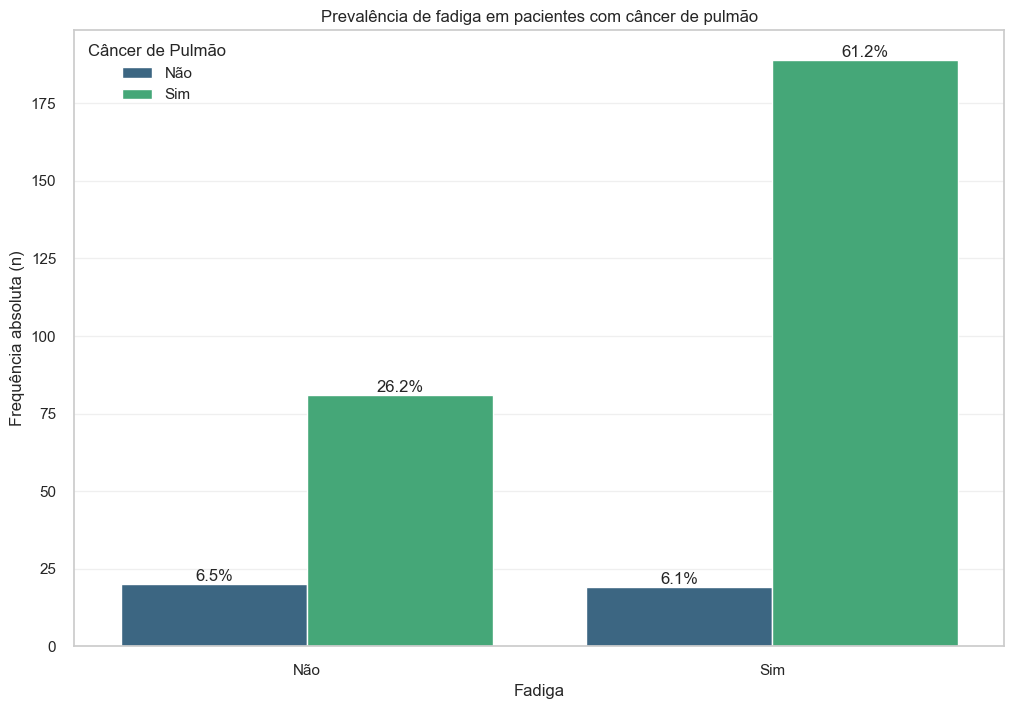

In [11]:
sns.set_theme(style="whitegrid")

ax = sns.countplot(
    data=df,
    x="fatigue",
    hue="lung_cancer",
    order=[0, 1],
    palette="viridis"
)

### calculando a porcenmtagem para as barras
total = len(df)

for p in ax.patches:
    altura = p.get_height()
    
    if altura == 0:   # ignora barras invisíveis
        continue
    
    porcentagem = 100 * altura / total
    
    ax.annotate(
        f'{porcentagem:.1f}%',
        (p.get_x() + p.get_width() / 2, altura),
        ha='center',
        va='bottom'
    )
#### renomeando labels do eixo X
ax.set_xticks([0, 1])
ax.set_xticklabels(["Não", "Sim"])

#### Alterndo label da legenda 
handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles,
    ["Não", "Sim"],   # ordem depende de como está no dataset
    title="Câncer de Pulmão"
)

### Parte escrita 
plt.title("Prevalência de fadiga em pacientes com câncer de pulmão")
plt.xlabel("Fadiga")
plt.ylabel("Frequência absoluta (n)")
plt.show()

### Presença de doenças crônicas 

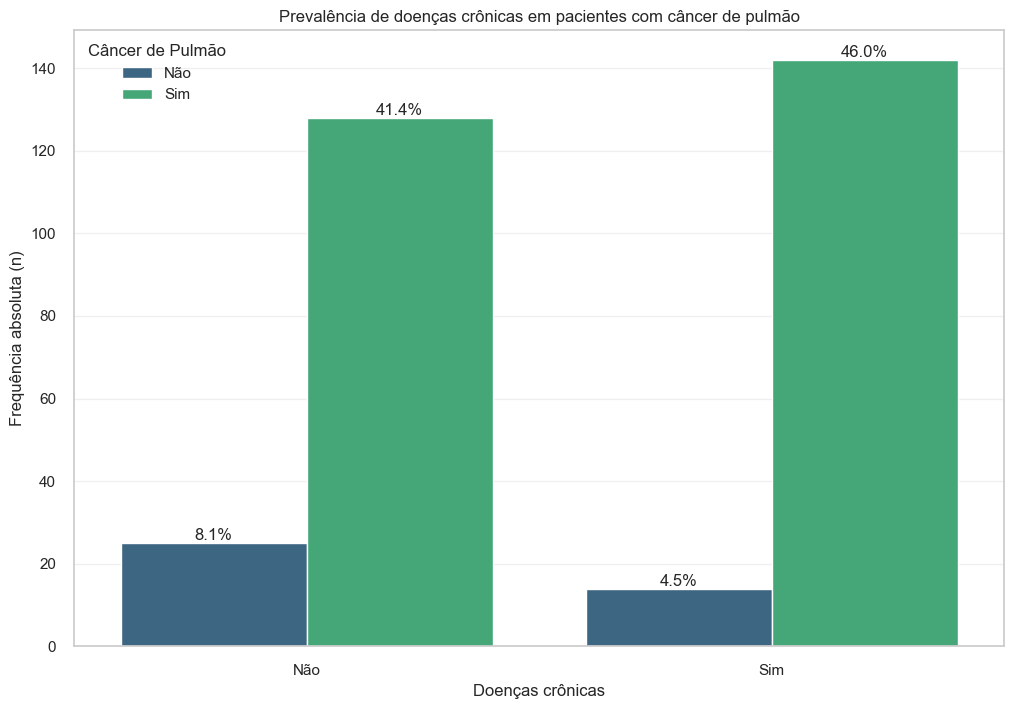

In [12]:
sns.set_theme(style="whitegrid")

ax = sns.countplot(
    data=df,
    x="chronic_disease",
    hue="lung_cancer",
    order=[0, 1],
    palette="viridis"
)

### calculando a porcenmtagem para as barras
total = len(df)

for p in ax.patches:
    altura = p.get_height()
    
    if altura == 0:   # ignora barras invisíveis
        continue
    
    porcentagem = 100 * altura / total
    
    ax.annotate(
        f'{porcentagem:.1f}%',
        (p.get_x() + p.get_width() / 2, altura),
        ha='center',
        va='bottom'
    )
#### renomeando labels do eixo X
ax.set_xticks([0, 1])
ax.set_xticklabels(["Não", "Sim"])

#### Alterndo label da legenda 
handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles,
    ["Não", "Sim"],   # ordem depende de como está no dataset
    title="Câncer de Pulmão"
)

### Parte escrita 
plt.title("Prevalência de doenças crônicas em pacientes com câncer de pulmão")
plt.xlabel("Doenças crônicas")
plt.ylabel("Frequência absoluta (n)")
plt.show()

#### Presença de consumo de álcool

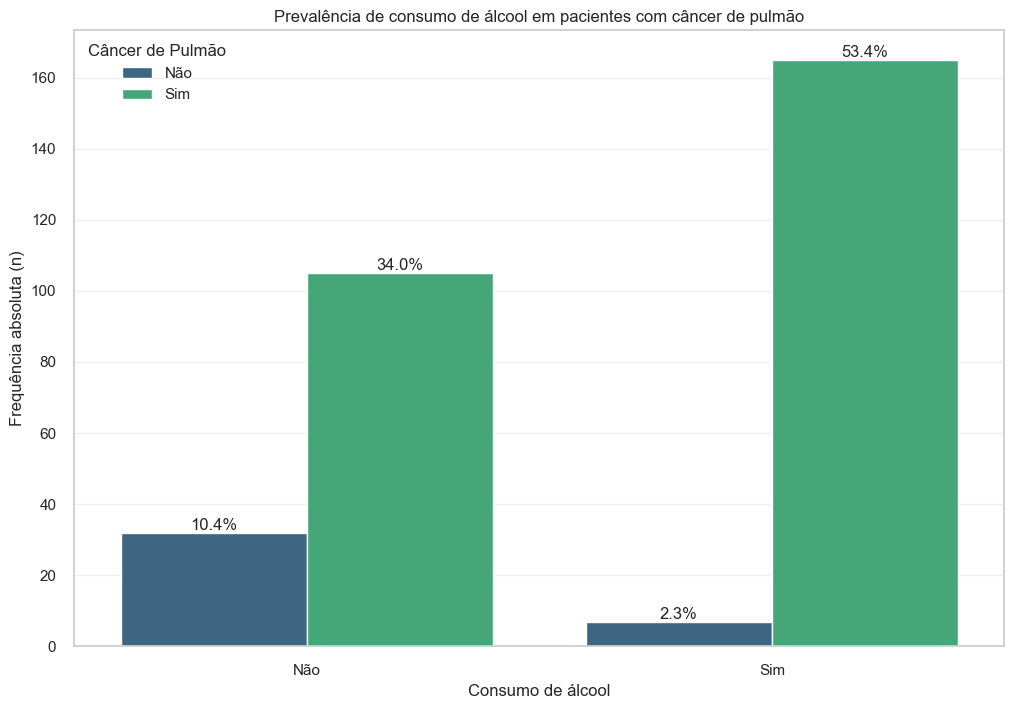

In [13]:
sns.set_theme(style="whitegrid")

ax = sns.countplot(
    data=df,
    x="alcohol_consuming",
    hue="lung_cancer",
    order=[0, 1],
    palette="viridis"
)

### calculando a porcenmtagem para as barras
total = len(df)

for p in ax.patches:
    altura = p.get_height()
    
    if altura == 0:   # ignora barras invisíveis
        continue
    
    porcentagem = 100 * altura / total
    
    ax.annotate(
        f'{porcentagem:.1f}%',
        (p.get_x() + p.get_width() / 2, altura),
        ha='center',
        va='bottom'
    )
#### renomeando labels do eixo X
ax.set_xticks([0, 1])
ax.set_xticklabels(["Não", "Sim"])

#### Alterndo label da legenda 
handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles,
    ["Não", "Sim"],   # ordem depende de como está no dataset
    title="Câncer de Pulmão"
)

### Parte escrita 
plt.title("Prevalência de consumo de álcool em pacientes com câncer de pulmão")
plt.xlabel("Consumo de álcool")
plt.ylabel("Frequência absoluta (n)")
plt.show()

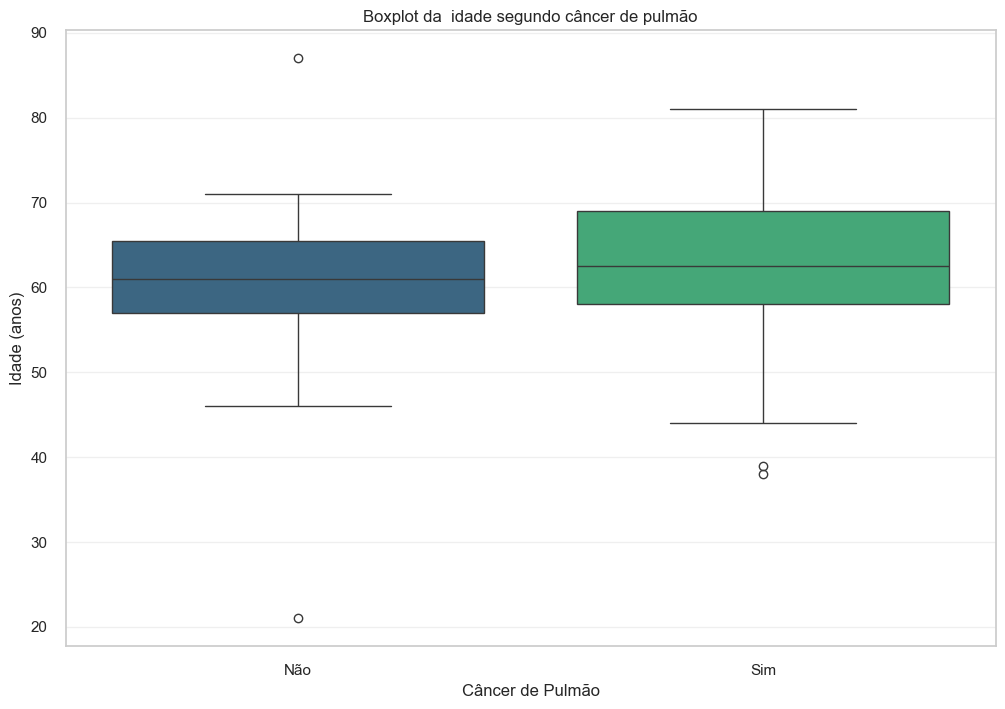

In [14]:
sns.set_theme(style="whitegrid")

ax = sns.boxplot(
    data=df,
    x="lung_cancer",   # categórica
    y="age",           # numérica
    order=[0, 1],
    palette="viridis"
)
ax.set_xticklabels(["Não", "Sim"])

handles, labels = ax.get_legend_handles_labels()

plt.title("Boxplot da  idade segundo câncer de pulmão")
plt.xlabel("Câncer de Pulmão")
plt.ylabel("Idade (anos)")
plt.show()

### Pré-processamento

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold, cross_validate
#from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder # standard scaler quando usamos algoritmos diferentes de árvore
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    balanced_accuracy_score
)

# ---------------------
# Separando o dataset

X = df.drop(columns=['lung_cancer'])
y = df['lung_cancer']

# ---------------------
# Dividir primeiro em treino e teste 
# ---------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # importante se for classificação, divide em proporção igual a distribuição
)


#Dividir treino em treino e validacao 
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.25,   # 25% de 80% = 20% do total
    random_state=42,
    stratify=y_train
)
### Portanto, 60% treino, 20% validação e 20 teste
# ---------------------
#  Pipeline final-----------
# separando coluna numérica
num_cols = ["age"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols)
    ],
    remainder="passthrough"  # mantém as binárias como estão
)





#### Treinamento de modelos 
model_1 = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

model_2 = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', ExtraTreesClassifier(random_state=42))
])

model_3 = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', AdaBoostClassifier(random_state=42))
])

model_4 = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', SVC(probability=True, random_state=42))
])

model_5 = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier',  LogisticRegression(random_state=42))
])

model_6 = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier',  GradientBoostingClassifier(random_state=42))
])
# ---------------------
#  Treinar
# ---------------------
model_1.fit(X_train, y_train)
model_2.fit(X_train, y_train)
model_3.fit(X_train, y_train)
model_4.fit(X_train, y_train)
model_5.fit(X_train, y_train)
model_6.fit(X_train, y_train)
# ---------------------
# Avaliar
# ---------------------

def avaliar_modelos_tabela(modelos, X_val, y_val):
    
    resultados = []
    
    for nome, modelo in modelos.items():
        
        y_pred = modelo.predict(X_val)
        y_prob = modelo.predict_proba(X_val)[:, 1]
        
        acc = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred)
        rec = recall_score(y_val, y_pred)  # sensibilidade
        f1 = f1_score(y_val, y_pred)
        auc = roc_auc_score(y_val, y_prob)
        pr_auc = average_precision_score(y_val, y_prob)
        bal_acc = balanced_accuracy_score(y_val, y_pred)
        
        # Especificidade
        tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
        especificidade = tn / (tn + fp)
        
        resultados.append({
            "Modelo": nome,
            "Accuracy": acc,
            "Sensibilidade": rec,
            "Especificidade": especificidade,
            "Precisão": prec,
            "F1-score": f1,
            "ROC-AUC": auc,
            "PR-AUC": pr_auc,
            "Balanced Accuracy": bal_acc
        })
    
    df_resultados = pd.DataFrame(resultados)
    
    return df_resultados

In [24]:
modelos = {
    "Random Forest": model_1,
    "Extra Trees": model_2,
    "AdaBoost": model_3,
    "SVM": model_4,
    "Logistic Regression": model_5,
    "Gradient Boosting": model_6
}

df_metricas = avaliar_modelos_tabela(modelos, X_val, y_val)

df_metricas.round(3)
df_metricas.sort_values("ROC-AUC", ascending=False)

,Modelo,Accuracy,Sensibilidade,Especificidade,Precisão,F1-score,ROC-AUC,PR-AUC,Balanced Accuracy
4,Logistic Regression,0.951613,0.981481,0.750,0.963636,0.972477,0.937500,0.990034,0.865741
1,Extra Trees,0.935484,0.962963,0.750,0.962963,0.962963,0.934028,0.988703,0.856481
0,Random Forest,0.935484,0.981481,0.625,0.946429,0.963636,0.928241,0.987372,0.803241
3,SVM,0.919355,0.981481,0.500,0.929825,0.954955,0.923611,0.988338,0.740741
2,AdaBoost,0.903226,0.944444,0.625,0.944444,0.944444,0.909722,0.985230,0.784722
5,Gradient Boosting,0.935484,0.962963,0.750,0.962963,0.962963,0.909722,0.983731,0.856481


#### Cross validation (5 amostras) e média do AUC

In [25]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelos = {
    "Random Forest": model_1,
    "Extra Trees": model_2,
    "AdaBoost": model_3,
    "SVM": model_4,
    "Logistic Regression": model_5,
    "Gradient Boosting": model_6
}

resultados = []
folds_plot = []

for nome, modelo in modelos.items():
    scores = cross_validate(
        modelo,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc"
    )
    
    auc = scores["test_score"]
    
    resultados.append({
        "Modelo": nome,
        "AUC (média)": auc.mean(),
        "Desvio padrão": auc.std()
    })
    
    for fold_score in auc:
        folds_plot.append({
            "Modelo": nome,
            "AUC": fold_score
        })

df_resultados = pd.DataFrame(resultados)
df_folds = pd.DataFrame(folds_plot)

df_resultados
df_resultados.round(3)
df_resultados.sort_values("AUC (média)", ascending=False)

,Modelo,AUC (média),Desvio padrão
4,Logistic Regression,0.940833,0.039272
2,AdaBoost,0.915701,0.034300
0,Random Forest,0.905284,0.042485
5,Gradient Boosting,0.897045,0.060994
3,SVM,0.885720,0.042375
1,Extra Trees,0.864697,0.081242


### Distribuição da AUC (5-fold CV)

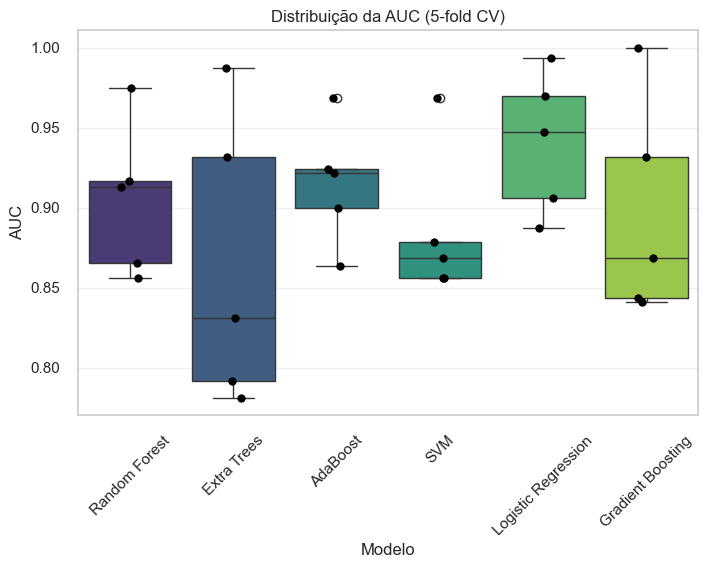

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df_folds, x="Modelo", y="AUC", whis=1.5, linewidth=1, palette="viridis")
sns.stripplot(data=df_folds, x="Modelo", y="AUC", size=6, color="black")

plt.xticks(rotation=45)
plt.title("Distribuição da AUC (5-fold CV)")
plt.ylabel("AUC")
plt.xlabel("Modelo")

plt.show()

### Resultados nos dados de validação 

In [18]:
for _, row in df_resultados.iterrows():
    print(
        f"{row['Modelo']} apresentou AUC média de "
        f"{row['AUC (média)']:.2f} ± {row['Desvio padrão']:.2f} "
        f"na validação cruzada estratificada de 5 folds."
    )

Random Forest apresentou AUC média de 0.91 ± 0.04 na validação cruzada estratificada de 5 folds.
Extra Trees apresentou AUC média de 0.86 ± 0.08 na validação cruzada estratificada de 5 folds.
AdaBoost apresentou AUC média de 0.92 ± 0.03 na validação cruzada estratificada de 5 folds.
SVM apresentou AUC média de 0.89 ± 0.04 na validação cruzada estratificada de 5 folds.
Logistic Regression apresentou AUC média de 0.94 ± 0.04 na validação cruzada estratificada de 5 folds.
Gradient Boosting apresentou AUC média de 0.90 ± 0.06 na validação cruzada estratificada de 5 folds.


### Predições no teste - Melhor modelo 

In [53]:
modelos = {
    "Logistic Regression": model_5,

}

df_metricas = avaliar_modelos_tabela(modelos, X_test, y_test)

df_metricas.round(3)
df_metricas.sort_values("ROC-AUC", ascending=False)

,Modelo,Accuracy,Sensibilidade,Especificidade,Precisão,F1-score,ROC-AUC,PR-AUC,Balanced Accuracy
0,Logistic Regression,0.919355,0.962963,0.625,0.945455,0.954128,0.956019,0.993874,0.793981


In [47]:
# Modelo final já treinado no treino completo
modelo_final = model_5  # exemplo

y_test_pred = modelo_final.predict(X_test)
y_test_prob = modelo_final.predict_proba(X_test)[:, 1]

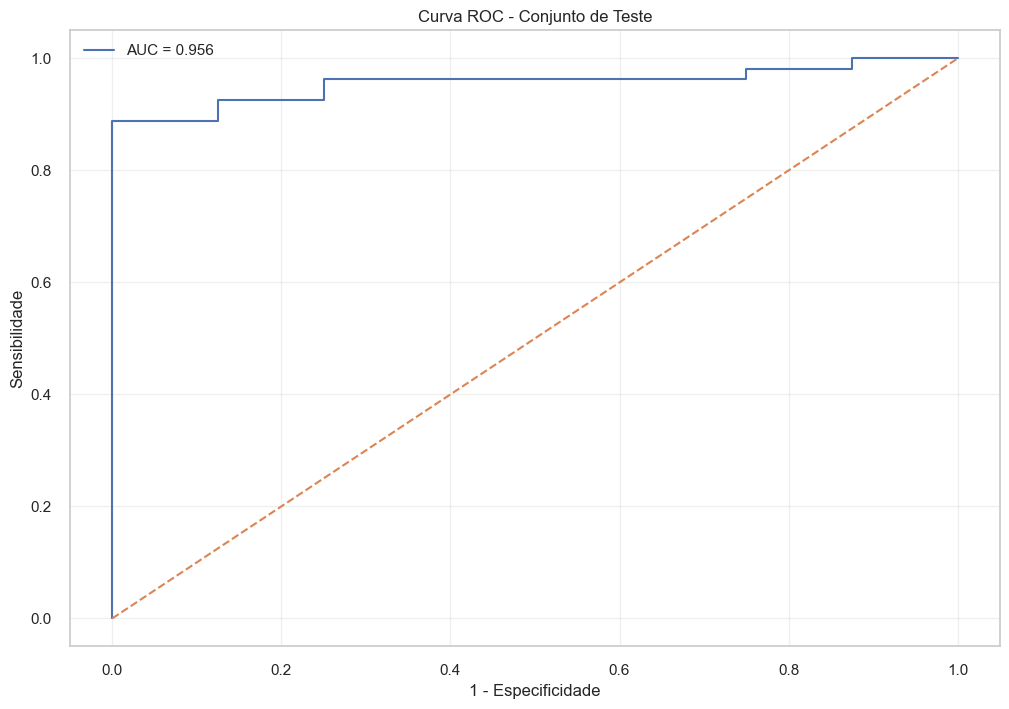

In [48]:
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("1 - Especificidade")
plt.ylabel("Sensibilidade")
plt.title("Curva ROC - Conjunto de Teste")
plt.legend()
plt.show()

### Curva Precision-Recall - Melhor modelo 

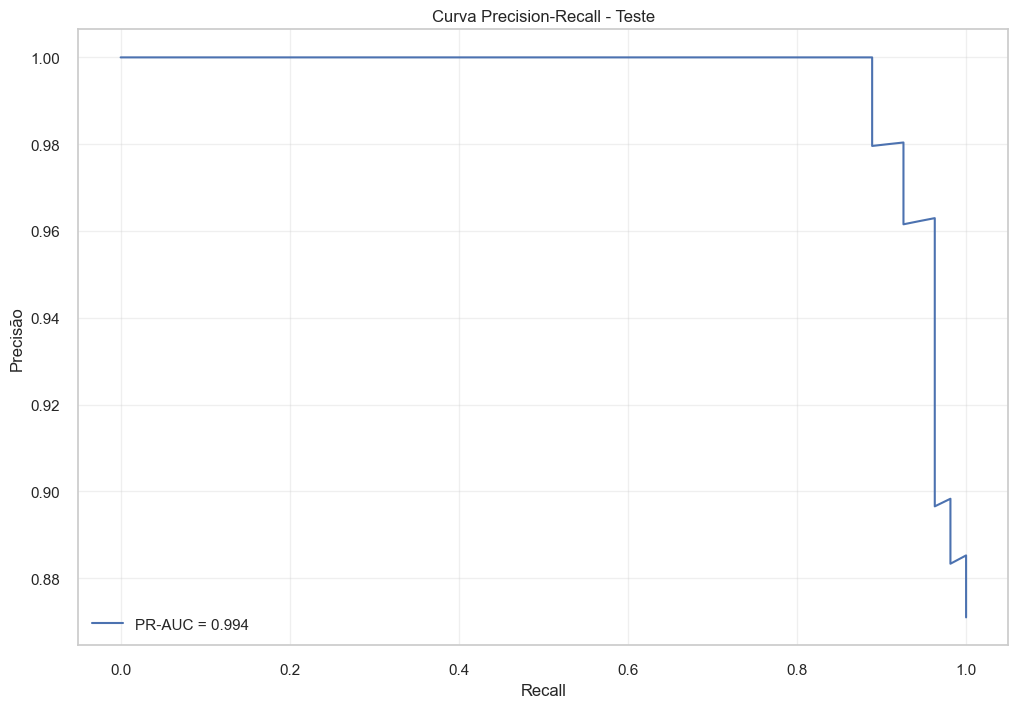

In [29]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, y_test_prob)
pr_auc = average_precision_score(y_test, y_test_prob)

plt.figure()
plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precisão")
plt.title("Curva Precision-Recall - Teste")
plt.legend()
plt.show()

## Bootstrap para gerar o intervalo de confiança da predição

### Resultados Finais do melhor modelo

In [35]:
import numpy as np
from sklearn.metrics import roc_auc_score, accuracy_score

n_bootstraps = 2000
rng = np.random.RandomState(42)

auc_scores = []
acc_scores = []

for _ in range(n_bootstraps):
    indices = rng.randint(0, len(y_test), len(y_test))
    
    if len(np.unique(y_test.iloc[indices])) < 2:
        continue
    
    auc_scores.append(
        roc_auc_score(y_test.iloc[indices], y_test_prob[indices])
    )
    
    acc_scores.append(
        accuracy_score(y_test.iloc[indices], y_test_pred[indices])
    )

auc_ci = np.percentile(auc_scores, [2.5, 97.5])
acc_ci = np.percentile(acc_scores, [2.5, 97.5])

resultado_final = pd.DataFrame({
    "Métrica": ["AUC", "Accuracy"],
    "Estimativa": [roc_auc, accuracy_score(y_test, y_test_pred)],
    "IC 2.5%": [auc_ci[0], acc_ci[0]],
    "IC 97.5%": [auc_ci[1], acc_ci[1]]
})

resultado_final

,Métrica,Estimativa,IC 2.5%,IC 97.5%
0,AUC,0.956019,0.899303,0.997911
1,Accuracy,0.919355,0.838710,0.983871


### Curvas ROC - Teste

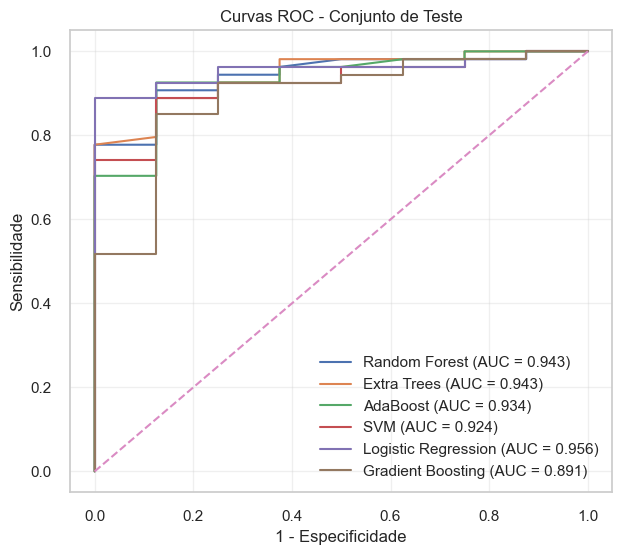

In [36]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

for nome, modelo in modelos.items():
    
    y_prob = modelo.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{nome} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("1 - Especificidade")
plt.ylabel("Sensibilidade")
plt.title("Curvas ROC - Conjunto de Teste")
plt.legend()
plt.show()

### Curvas Precision-Recall - Teste

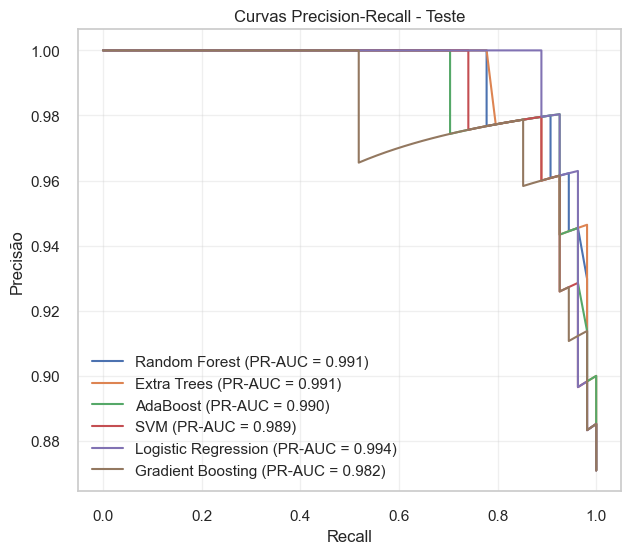

In [37]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(7,6))

for nome, modelo in modelos.items():
    
    y_prob = modelo.predict_proba(X_test)[:,1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    
    plt.plot(recall, precision, label=f"{nome} (PR-AUC = {pr_auc:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precisão")
plt.title("Curvas Precision-Recall - Teste")
plt.legend()
plt.show()